# Customer Churn & Retention Analysis

This project analyzes customer behavior and service usage data to identify key factors contributing to churn and uncover opportunities to improve customer retention.

## Questions Explored

- What is the overall churn rate?
- Which customer segments are most likely to churn?
- How do contract types impact churn?
- Does tenure influence customer retention?
- What role do pricing and services play in churn behavior?

## Tools Used

- Python  
- Pandas  
- Matplotlib  
- Seaborn  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()

In [2]:
df = pd.read_csv("Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 🧹 Data Cleaning & Preparation

Before analysis, the dataset is cleaned to ensure accuracy and consistency.

This includes converting data types, handling missing values, and preparing the target variable for analysis.

### Key Steps:

- Convert `TotalCharges` to a numeric format  
- Handle missing or invalid values  
- Encode the `Churn` column into a binary variable for analysis  

In [3]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop missing values
df = df.dropna()

# Convert Churn to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   gender            7032 non-null   object 
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   object 
 4   Dependents        7032 non-null   object 
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   object 
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   object 
 17  

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441,0.265785
std,0.368844,24.545260,30.085974,2266.771362,0.441782
min,0.000000,1.000000,18.250000,18.800000,0.000000
25%,0.000000,9.000000,35.587500,401.450000,0.000000
50%,0.000000,29.000000,70.350000,1397.475000,0.000000
75%,0.000000,55.000000,89.862500,3794.737500,1.000000
max,1.000000,72.000000,118.750000,8684.800000,1.000000


## 📊 Exploratory Data Analysis

With the dataset cleaned and prepared, the next step is to explore patterns and relationships within the data.

This phase focuses on understanding customer behavior, identifying trends, and uncovering key factors that contribute to churn.

### Areas of Focus:

- Overall churn distribution  
- Customer tenure and retention patterns  
- Impact of pricing on churn  
- Influence of contract types and services  

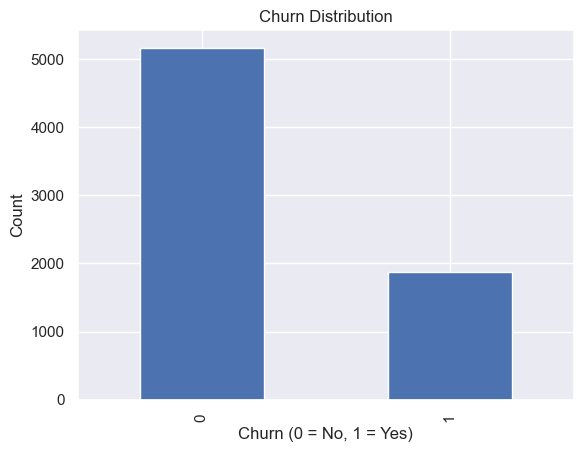

In [5]:
plt.figure()
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

### 📌 Insight: Churn Distribution

The dataset shows a clear imbalance between customers who churned and those who remained.

- The majority of customers did **not churn**
- A significant portion still left, indicating a **meaningful churn problem**

This suggests that while retention is generally strong, there is a sizable group of customers at risk, making churn prediction and prevention an important business focus.

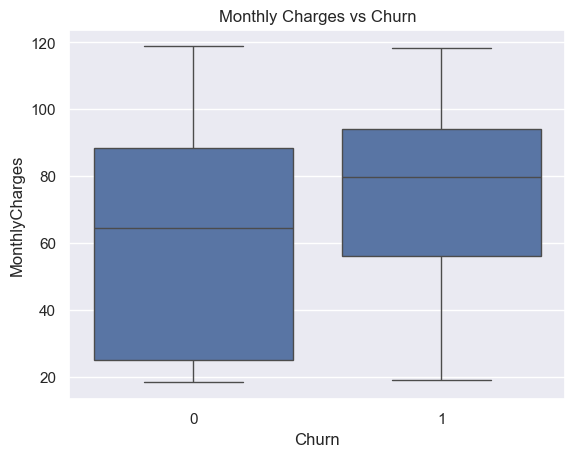

In [6]:
plt.figure()
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

### 📌 Insight: Monthly Charges vs Churn

Customers who churn tend to have **higher monthly charges** compared to those who stay.

- The median monthly charge is noticeably higher for churned customers  
- There is greater concentration of higher-priced plans among those who leave  

This suggests that **pricing may be a key driver of churn**, where customers on more expensive plans are more likely to discontinue the service.

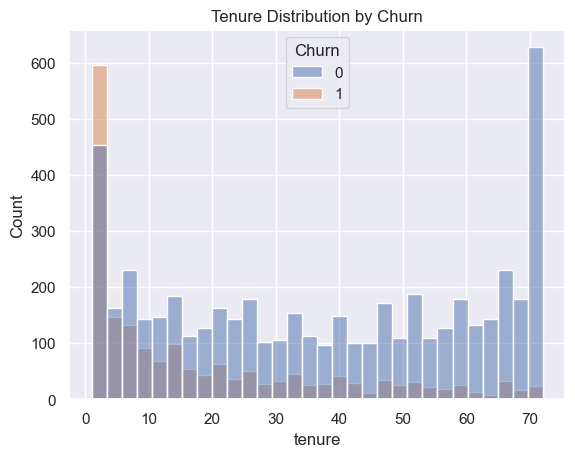

In [7]:
plt.figure()
sns.histplot(data=df, x='tenure', hue='Churn', bins=30)
plt.title("Tenure Distribution by Churn")
plt.show()

### 📌 Insight: Tenure vs Churn

Customers who churn are heavily concentrated in the **early stages of their tenure**.

- A large portion of churn occurs within the **first few months**  
- Long-term customers (higher tenure) are significantly more likely to stay  
- Churn decreases as customer tenure increases  

This suggests that **early customer experience is critical**, and improving onboarding and initial engagement could significantly reduce churn rates.

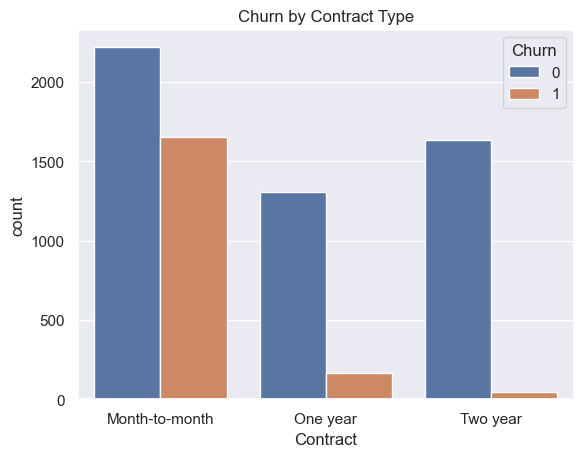

In [8]:
plt.figure()
sns.countplot(data=df, x='Contract', hue='Churn')
plt.title("Churn by Contract Type")
plt.show()

### 📌 Insight: Contract Type vs Churn

Customers on **month-to-month contracts** have the highest churn rate by a significant margin.

- Month-to-month customers show a much higher likelihood of churning  
- Customers with **one-year and two-year contracts** are far more likely to stay  
- Longer contract commitments strongly correlate with customer retention  

This suggests that **contract length plays a critical role in retention**, where longer-term agreements reduce the likelihood of churn.

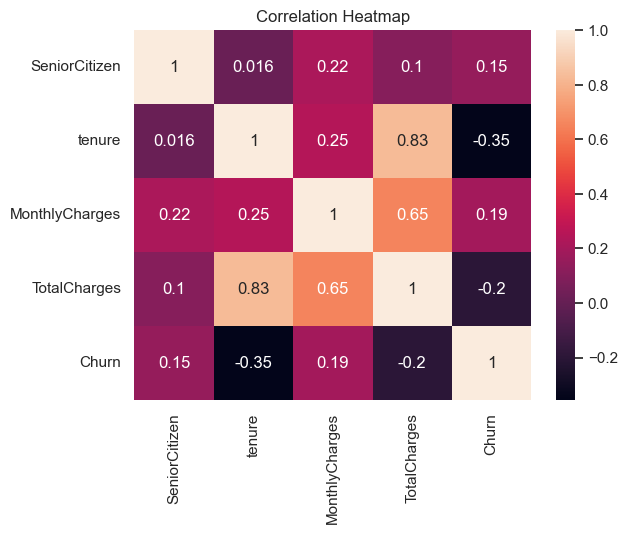

In [9]:
plt.figure()
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

### 📌 Insight: Correlation Analysis

The correlation heatmap highlights relationships between numerical features and churn.

- **Tenure has a negative correlation with churn (-0.35)**, indicating that longer-term customers are less likely to leave  
- **MonthlyCharges show a slight positive correlation with churn (0.19)**, suggesting higher costs may contribute to customer loss  
- **TotalCharges is negatively correlated with churn (-0.20)**, reinforcing that long-term, higher-value customers tend to stay  

Overall, tenure emerges as the **strongest predictor of churn**, while pricing also plays a contributing role.

## 🧾 Conclusion & Key Takeaways

This analysis explored customer behavior to identify the main drivers of churn and uncover opportunities to improve retention.

### Key Findings:

- Customers on **month-to-month contracts** have the highest churn rates  
- **New customers (low tenure)** are significantly more likely to leave  
- Customers with **higher monthly charges** show increased churn behavior  
- Long-term customers demonstrate **strong retention and lower churn risk**  

### Business Implications:

The findings suggest that churn is primarily driven by **lack of commitment, early-stage disengagement, and pricing sensitivity**.

To improve retention, businesses should focus on:

- Enhancing the **early customer experience and onboarding process**  
- Encouraging **long-term contracts** through incentives or pricing strategies  
- Providing **greater value for higher-priced plans**  
- Identifying and targeting **high-risk customers early in their lifecycle**  

Overall, this analysis demonstrates how data can be used to uncover actionable insights and support strategic decision-making in customer retention.